In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
%config IPCompleter.greedy=True
%config IPCompleter.use_jedi = False

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [4]:
df = pd.read_csv("3-customersatisfaction.csv")

In [5]:
df

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365
...,...,...,...
95,95,2.055072,8.686851
96,96,0.864149,2.901486
97,97,-1.586101,0.786207
98,98,1.558528,5.447475


In [6]:
df.head() # bizim için önemli olan müşteri puanlarıdır o yüzden unnamed silsek olur

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [7]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [8]:
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


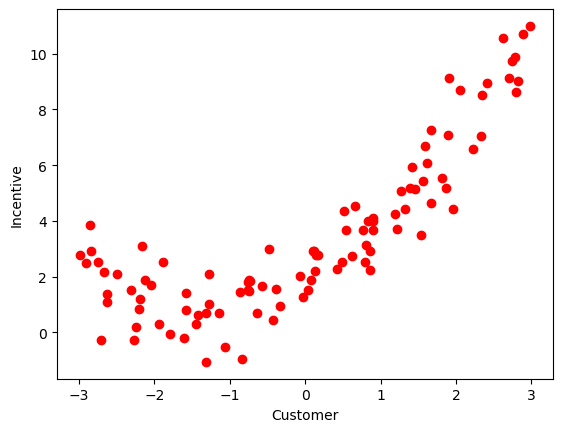

In [10]:
plt.scatter(df["Customer Satisfaction"],df["Incentive"],color="r")
plt.xlabel("Customer")
plt.ylabel("Incentive")
plt.show()

In [11]:
# tablomuz polinom görğmğnde çıktı

In [12]:
# 1 - dependent and indepent features

In [13]:
X = df[["Customer Satisfaction"]]
y = df["Incentive"]

In [14]:
X.head()

,Customer Satisfaction
0,-1.282447
1,0.425298
2,1.953070
3,2.625838
4,-1.426333


In [15]:
y.head()

0     1.010513
1     2.281043
2     4.415053
3    10.563600
4     0.627365
Name: Incentive, dtype: float64

In [16]:
# 2 - test train split

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [18]:
X_train

,Customer Satisfaction
99,0.512504
3,2.625838
20,-0.865714
55,-1.145369
6,2.823460
...,...
28,1.191020
0,-1.282447
5,-1.311432
12,0.490521


In [19]:
X_test

,Customer Satisfaction
84,0.785942
36,0.142978
57,-1.282120
51,1.910583
46,-0.029488
78,1.541346
93,0.810527
14,0.072354
11,1.449716
59,-2.315315


In [20]:
# 3 - scaler

In [21]:
scaler = StandardScaler()

In [22]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
regression = LinearRegression()

In [24]:
regression.fit(X_train,y_train)

LinearRegression()

In [25]:
# 4 - prediction

In [26]:
y_pred = regression.predict(X_test)

In [27]:
y_pred

array([ 4.65663741,  3.71913877,  1.64121789,  6.29646523,  3.46766736,
        5.7580845 ,  4.692485  ,  3.61616231,  5.62448003,  0.13472702,
        4.47909659,  4.8130839 ,  1.58319087,  0.30515983,  5.27634309,
        0.41711005, -0.7385295 , -0.32653914,  3.55906887,  1.19798631])

In [28]:
score = r2_score(y_test,y_pred)
print(score) # çok kötü bir r square skoru

0.2705652535622246


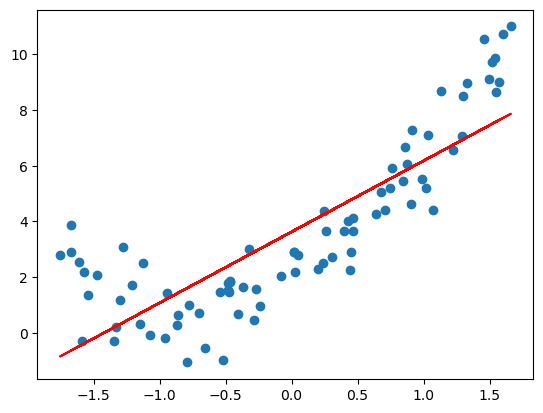

In [29]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color="r")
plt.show()

In [30]:
# resgresyonumuzu polinom hale getirmemiz lazım

In [31]:
poly = PolynomialFeatures() # bu tarz komutlar sclkit learn sayfasında bakıp ögrenebilirsin iç kısmının nasıl doldurulacagını

In [32]:
poly = PolynomialFeatures(degree=2,include_bias=True)# yukarıyla hiçbir farkı sadece degree egiştirme yapıcaz biz

In [33]:
# include_bias, veriye tamamı 1'lerden oluşan yapay bir sütun ekleyerek formüldeki sabit terimin (kesim noktasının) hesaplanmasını sağlayan bir ayardır

In [34]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [35]:
X_train_poly

array([[ 1.00000000e+00,  2.47633535e-01,  6.13223675e-02],
       [ 1.00000000e+00,  1.45565669e+00,  2.11893639e+00],
       [ 1.00000000e+00, -5.40182671e-01,  2.91797318e-01],
       [ 1.00000000e+00, -7.00039198e-01,  4.90054879e-01],
       [ 1.00000000e+00,  1.56862116e+00,  2.46057233e+00],
       [ 1.00000000e+00,  9.87568378e-01,  9.75291302e-01],
       [ 1.00000000e+00,  4.48640749e-01,  2.01278522e-01],
       [ 1.00000000e+00,  1.54377517e+00,  2.38324178e+00],
       [ 1.00000000e+00,  1.33219938e+00,  1.77475518e+00],
       [ 1.00000000e+00, -4.80410926e-01,  2.30794658e-01],
       [ 1.00000000e+00,  3.92892957e-01,  1.54364876e-01],
       [ 1.00000000e+00, -6.57456685e-01,  4.32249293e-01],
       [ 1.00000000e+00,  4.42663768e-01,  1.95951211e-01],
       [ 1.00000000e+00, -8.72131603e-01,  7.60613533e-01],
       [ 1.00000000e+00, -1.57257044e+00,  2.47297780e+00],
       [ 1.00000000e+00, -4.70184630e-01,  2.21073587e-01],
       [ 1.00000000e+00, -8.36083500e-02

In [36]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

LinearRegression()

In [37]:
y_pred = regression.predict(X_test_poly)
r2_score(y_test,y_pred)


0.7685687698788557

In [38]:
regression.coef_

array([0.        , 2.63871762, 1.54959954])

In [39]:
regression.intercept_

np.float64(2.076676429793282)

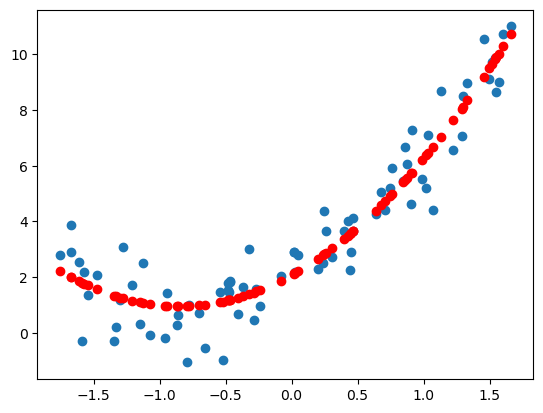

In [40]:
plt.scatter(X_train,y_train)
plt.scatter(X_train,regression.predict(X_train_poly),color="r")
plt.show()

In [41]:
poly = PolynomialFeatures(degree=3,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [42]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.7573443621401048


In [43]:
# degree 2 den 3 çekkincede çok fazla bir şey degişmedi

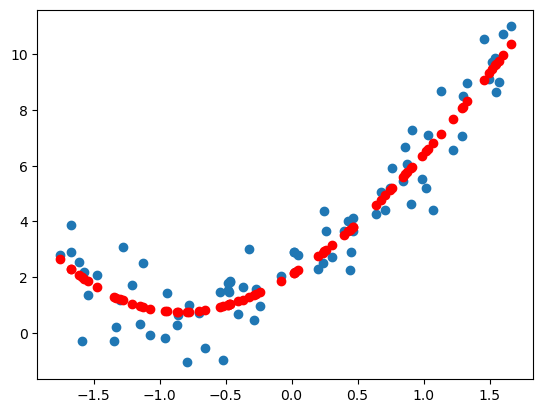

In [44]:
plt.scatter(X_train,y_train)
plt.scatter(X_train,regression.predict(X_train_poly),color="r")
plt.show()

In [45]:
# degree 2 de tutmak en matıklısı oldu

In [46]:
# new data

In [47]:
new_df = pd.read_csv("3-newdatas.csv")

In [48]:
new_df

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [49]:
new_df.rename(columns={"0":"Customer Satisfaction"},inplace=True) # kolonumuzda ad yoktu ad eklemiş olduk

In [50]:
new_df

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [52]:
X_new = new_df[["Customer Satisfaction"]]

In [53]:
X_new

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [54]:
scaler.fit_transform(X_new)

array([[-1.7234121 ],
       [-1.70609137],
       [-1.68877065],
       [-1.67144992],
       [-1.6541292 ],
       [-1.63680847],
       [-1.61948775],
       [-1.60216702],
       [-1.5848463 ],
       [-1.56752558],
       [-1.55020485],
       [-1.53288413],
       [-1.5155634 ],
       [-1.49824268],
       [-1.48092195],
       [-1.46360123],
       [-1.4462805 ],
       [-1.42895978],
       [-1.41163905],
       [-1.39431833],
       [-1.3769976 ],
       [-1.35967688],
       [-1.34235616],
       [-1.32503543],
       [-1.30771471],
       [-1.29039398],
       [-1.27307326],
       [-1.25575253],
       [-1.23843181],
       [-1.22111108],
       [-1.20379036],
       [-1.18646963],
       [-1.16914891],
       [-1.15182818],
       [-1.13450746],
       [-1.11718674],
       [-1.09986601],
       [-1.08254529],
       [-1.06522456],
       [-1.04790384],
       [-1.03058311],
       [-1.01326239],
       [-0.99594166],
       [-0.97862094],
       [-0.96130021],
       [-0

In [55]:
X_new_poly = poly.transform(X_new)

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


In [56]:
y_new = regression.predict(X_new_poly)

In [57]:
y_new

array([12.49035873, 12.13543673, 11.78673461, 11.4442174 , 11.10785014,
       10.77759787, 10.45342563, 10.13529845,  9.82318137,  9.51703944,
        9.21683769,  8.92254116,  8.63411489,  8.35152392,  8.07473328,
        7.80370801,  7.53841316,  7.27881376,  7.02487484,  6.77656146,
        6.53383864,  6.29667142,  6.06502485,  5.83886396,  5.61815379,
        5.40285938,  5.19294576,  4.98837798,  4.78912108,  4.59514009,
        4.40640005,  4.222866  ,  4.04450297,  3.87127602,  3.70315017,
        3.54009046,  3.38206193,  3.22902963,  3.08095858,  2.93781383,
        2.79956042,  2.66616338,  2.53758776,  2.41379858,  2.2947609 ,
        2.18043975,  2.07080016,  1.96580718,  1.86542584,  1.76962118,
        1.67835825,  1.59160207,  1.50931769,  1.43147015,  1.35802449,
        1.28894573,  1.22419893,  1.16374912,  1.10756134,  1.05560063,
        1.00783202,  0.96422056,  0.92473128,  0.88932922,  0.85797942,
        0.83064692,  0.80729675,  0.78789397,  0.77240359,  0.76

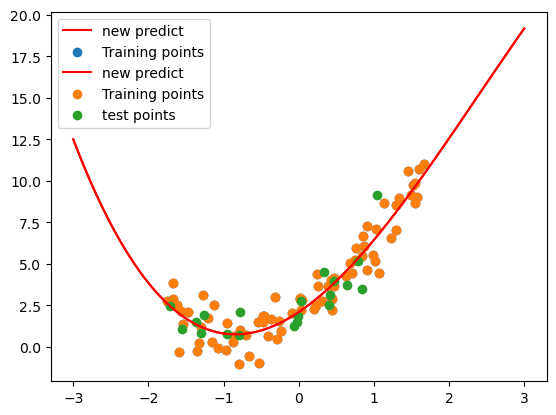

In [62]:
plt.plot(X_new,y_new,"r",label="new predict")
plt.scatter(X_train,y_train,label="Training points")
plt.scatter(X_test,y_test,label="test points")
plt.legend()
plt.show()

In [63]:
# PİPELİNE

In [70]:
def poly_regression (degree) :
    poly_features = PolynomialFeatures(degree=degree)
    scaler= StandardScaler()
    lin_reg = LinearRegression()
    pipeline = Pipeline([
        ("standard_scaler",scaler),
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
                         ])
    pipeline.fit(X_train,y_train)
    score = pipeline.score(X_test,y_test)
    print(score)
    
    

In [71]:
# pipeline kısaca stadarscale , poltfeatures ve linearra regresiyon adımllarını tek seferde yapıyor biziö için tek tek yazmamıza gerek kalmıyor

In [72]:
poly_regression(3)

0.7573443621401048


In [74]:
poly_regression(2)

0.7685687698788557


In [75]:
poly_regression(5)

0.7351244165095401


In [77]:
for degree in [1,2,3,4,5,6,7,8,9,10]:
    poly_regression(degree)

0.2705652535622246
0.7685687698788557
0.7573443621401048
0.7355034443260413
0.7351244165095401
0.734359048213343
0.7347819263549451
0.7411422099998385
0.7310763879815929
0.7280578621232854


In [83]:
def poly_regression (degree) :
    poly_features = PolynomialFeatures(degree=degree)
    scaler= StandardScaler()
    lin_reg = LinearRegression()
    pipeline = Pipeline([
        ("standard_scaler",scaler),
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
                         ])
    pipeline.fit(X_train,y_train)
    score = pipeline.score(X_test,y_test)
    print("R2 score",score)

    y_pred_new = pipeline.predict(X_new)
    plt.plot(X_new,y_pred_new,"r",label="new predict")
    plt.scatter(X_train,y_train,label="Training points")
    plt.scatter(X_test,y_test,label="test points")
    plt.legend()
    plt.show()

R2 score 0.2705652535622246


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


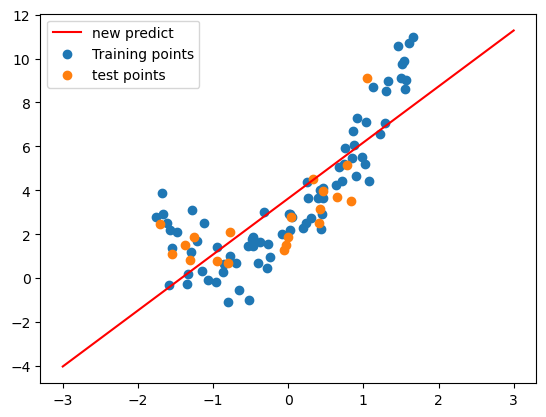

R2 score 0.7685687698788557


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


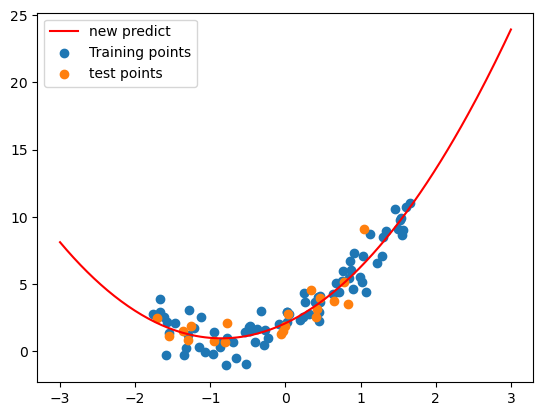

R2 score 0.7573443621401048


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


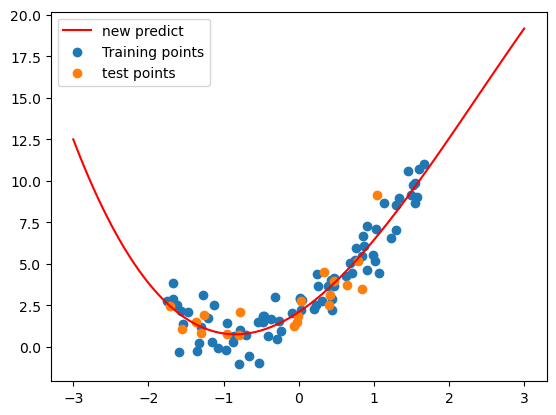

R2 score 0.7355034443260413


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


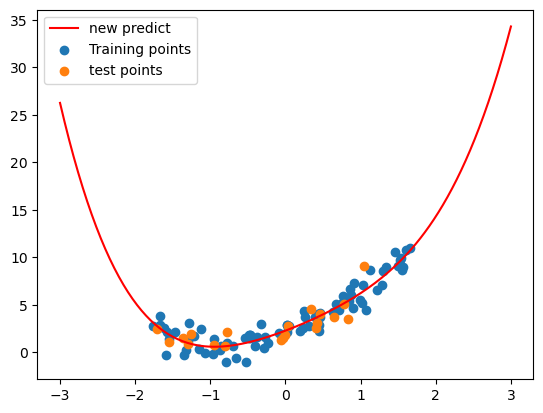

R2 score 0.7351244165095401


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


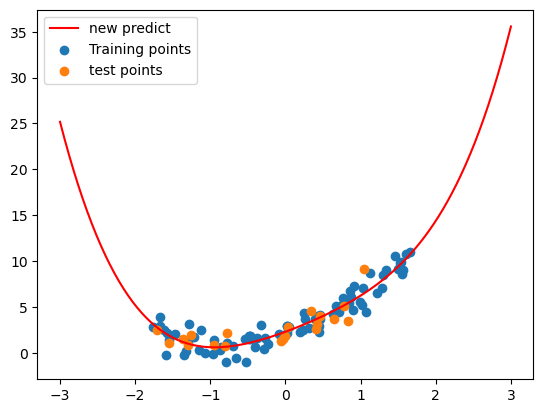

R2 score 0.734359048213343


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


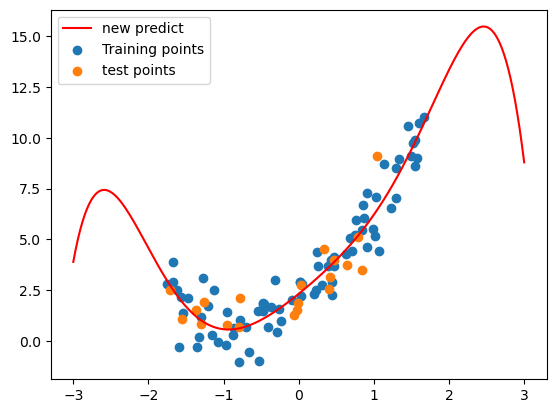

R2 score 0.7347819263549451


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


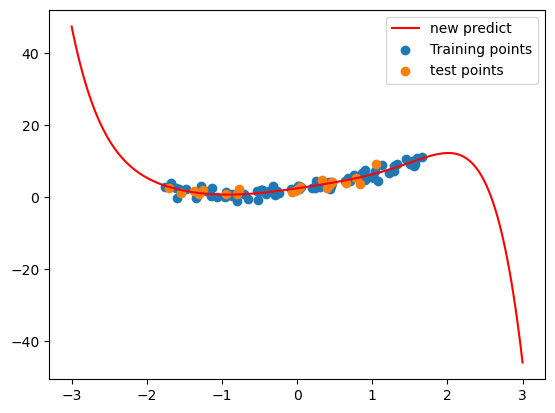

R2 score 0.7411422099998385


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


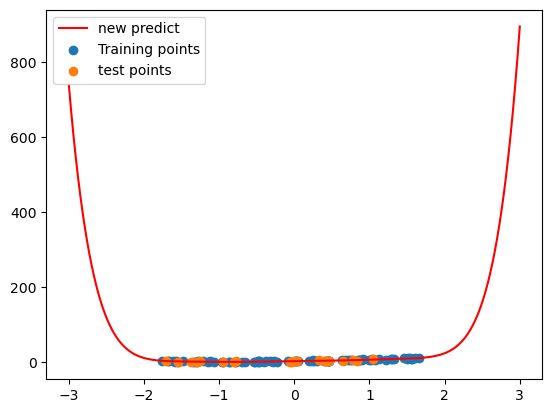

R2 score 0.7310763879815929


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


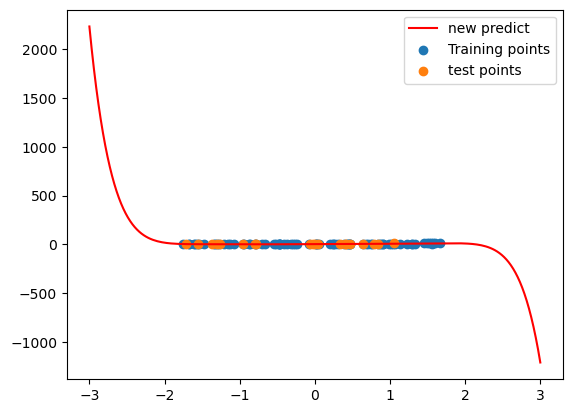

R2 score 0.7280578621232854


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


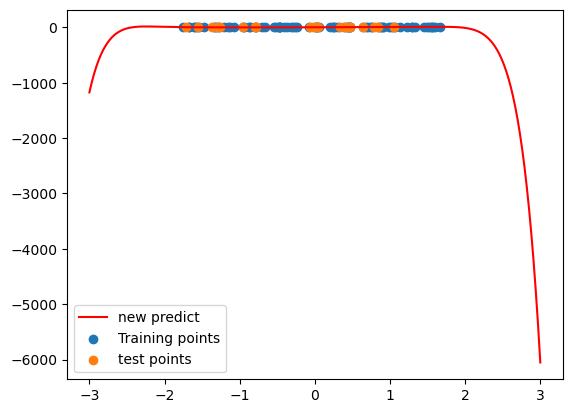

In [84]:
for degree in [1,2,3,4,5,6,7,8,9,10]:
    poly_regression(degree)